In [1]:
!pip install -q gdown

import gdown
import os
import zipfile
import shutil
import random

file_id = "1PwZXse2huPI_weaKCSq21Olu2ButPFyM"
output = "/kaggle/working/data.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

print("Download completed")



extract_path = "/kaggle/working/data"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed")


paths_to_delete = [
    "/kaggle/working/data/.config",
    "/kaggle/working/data/.ipynb_checkpoints",
    "/kaggle/working/data/all_folders.zip",
    "/kaggle/working/data/drive",
    "/kaggle/working/.virtual_documents"
]

for path in paths_to_delete:
    if os.path.isdir(path):
        shutil.rmtree(path)
        print(f"Deleted folder: {path}")
    elif os.path.isfile(path):
        os.remove(path)
        print(f"Deleted file: {path}")
    else:
        print(f"Path not found (skipped): {path}")


def split_classes_train_val(
    data_dir,
    train_ratio=0.8,
    seed=42,
    extensions=None
):
    """
    Splits each class folder into train/ and validation/ subfolders.

    Structure BEFORE:
    data/
        class1/
            img1.jpg
            img2.jpg
        class2/
            img1.jpg
            img2.jpg

    Structure AFTER:
    data/
        class1/
            train/
            validation/
        class2/
            train/
            validation/
    """

    random.seed(seed)

    classes = [
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ]

    for cls in classes:
        class_path = os.path.join(data_dir, cls)

        files = [
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ]

        if extensions:
            files = [f for f in files if f.lower().endswith(extensions)]

        if len(files) == 0:
            continue

        random.shuffle(files)

        split_idx = int(len(files) * train_ratio)
        train_files = files[:split_idx]
        val_files = files[split_idx:]

        train_dir = os.path.join(class_path, "train")
        val_dir = os.path.join(class_path, "validation")

        os.makedirs(train_dir, exist_ok=True)
        os.makedirs(val_dir, exist_ok=True)

        for f in train_files:
            shutil.move(
                os.path.join(class_path, f),
                os.path.join(train_dir, f)
            )

        for f in val_files:
            shutil.move(
                os.path.join(class_path, f),
                os.path.join(val_dir, f)
            )

        print(
            f"{cls}: "
            f"{len(train_files)} train, "
            f"{len(val_files)} validation"
        )
data_dir = "/kaggle/working/data"

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp",
    ".ppm", ".pgm", ".pbm"
)

split_classes_train_val(
    data_dir=data_dir,
    train_ratio=0.8,
    extensions=IMAGE_EXTENSIONS
)



def keep_only_train_val(data_dir):
    allowed = {"train", "validation"}

    classes = [
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ]

    for cls in classes:
        class_path = os.path.join(data_dir, cls)

        for item in os.listdir(class_path):
            item_path = os.path.join(class_path, item)

            if os.path.isdir(item_path) and item not in allowed:
                shutil.rmtree(item_path)
                print(f"Deleted: {item_path}")

data_dir = "/kaggle/working/data"
keep_only_train_val(data_dir)

Downloading...
From (original): https://drive.google.com/uc?id=1PwZXse2huPI_weaKCSq21Olu2ButPFyM
From (redirected): https://drive.google.com/uc?id=1PwZXse2huPI_weaKCSq21Olu2ButPFyM&confirm=t&uuid=cfeff6ae-832b-4e8b-9e48-23d0930571c3
To: /kaggle/working/data.zip
100%|██████████| 993M/993M [00:05<00:00, 183MB/s] 


Download completed
Extraction completed
Deleted folder: /kaggle/working/data/.config
Deleted folder: /kaggle/working/data/.ipynb_checkpoints
Deleted file: /kaggle/working/data/all_folders.zip
Deleted folder: /kaggle/working/data/drive
Deleted folder: /kaggle/working/.virtual_documents
Vacuum_cleaner_dataset: 800 train, 200 validation
Pitcher_dataset: 800 train, 200 validation
Chiffonier_dataset: 800 train, 200 validation
stove_dataset: 800 train, 200 validation
carpet_dataset: 800 train, 200 validation
Frying pan_dataset: 800 train, 200 validation
Waffle iron_dataset: 800 train, 200 validation
Salt Shaker_dataset: 800 train, 200 validation
wardrobe_dataset: 800 train, 200 validation
Crock pot_dataset: 800 train, 200 validation
Electric_fan_dataset: 800 train, 200 validation
microwave_dataset: 800 train, 200 validation
Mixing bowl_dataset: 800 train, 200 validation
Teapot_dataset: 800 train, 200 validation
Toaster_dataset: 800 train, 200 validation
Hand Blower_dataset: 800 train, 200 va

In [2]:
!pip install annoy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 16.3 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=549274 sha256=6b41861fc3f8d3a41ea2b2d4c7ef9e211a94da18b226b3adf25035a0a672262b
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


In [3]:
import os
import json
import torch
from torchvision import models, transforms
import torch.nn as nn
import numpy as np
from annoy import AnnoyIndex
from PIL import Image

# =========================
# SETTINGS
# =========================
DATA_DIR = "/kaggle/working/data"
IMG_SIZE = 224
EMBEDDING_DIM = 512  # ResNet18 output dimension after replacing fc with Identity
BATCH_SIZE = 32
N_TREES = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# LOAD RESNET18 MODEL
# =========================
weights = models.ResNet18_Weights.IMAGENET1K_V1
embedding_model = models.resnet18(weights=weights)
embedding_model.fc = nn.Identity()  # Remove final classification layer
embedding_model = embedding_model.to(DEVICE)
embedding_model.eval()

# =========================
# IMAGE PREPROCESS FUNCTION
# =========================
preprocess = weights.transforms()  # This handles resize, tensor conversion, and normalization

def preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = preprocess(img)
    return img

def create_dataset(image_paths):
    # Returns list of batches as tensors
    dataset = []
    batch = []
    for path in image_paths:
        img_tensor = preprocess_image(path)
        batch.append(img_tensor)
        if len(batch) == BATCH_SIZE:
            dataset.append(torch.stack(batch).to(DEVICE))
            batch = []
    if batch:
        dataset.append(torch.stack(batch).to(DEVICE))
    return dataset

# =========================
# BUILD INDEX PER CLASS
# =========================
for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)
    
    if not os.path.isdir(class_path):
        continue

    print(f"\nProcessing class: {class_name}")

    # Collect all image paths (train + validation)
    image_paths = []
    for split in ["train", "validation"]:
        split_path = os.path.join(class_path, split)
        if not os.path.exists(split_path):
            continue
        for filename in os.listdir(split_path):
            if filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                image_paths.append(os.path.join(split_path, filename))

    if len(image_paths) == 0:
        print("No images found.")
        continue

    print(f"Total images: {len(image_paths)}")

    # Create dataset batches
    dataset_batches = create_dataset(image_paths)

    # Create Annoy index
    index = AnnoyIndex(EMBEDDING_DIM, 'angular')
    item_index = 0

    # Extract embeddings in batches
    with torch.no_grad():
        for batch in dataset_batches:
            embeddings = embedding_model(batch)  # Shape: [batch_size, EMBEDDING_DIM]
            embeddings = embeddings.cpu().numpy()
            
            # Normalize batch (important for angular metric)
            norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
            embeddings = embeddings / norms

            for vector in embeddings:
                index.add_item(item_index, vector)
                item_index += 1

    # Build and save
    index.build(N_TREES)
    index_path = os.path.join(class_path, f"{class_name}.ann")
    index.save(index_path)

    # Save paths mapping
    paths_file = os.path.join(class_path, f"{class_name}_paths.json")
    with open(paths_file, "w") as f:
        json.dump(image_paths, f)

    print(f"Saved index for {class_name} with {item_index} items.")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]



Processing class: Vacuum_cleaner_dataset
Total images: 1000
Saved index for Vacuum_cleaner_dataset with 1000 items.

Processing class: Pitcher_dataset
Total images: 1000
Saved index for Pitcher_dataset with 1000 items.

Processing class: Chiffonier_dataset
Total images: 1000
Saved index for Chiffonier_dataset with 1000 items.

Processing class: stove_dataset
Total images: 1000
Saved index for stove_dataset with 1000 items.

Processing class: carpet_dataset
Total images: 1000
Saved index for carpet_dataset with 1000 items.

Processing class: Frying pan_dataset
Total images: 1000
Saved index for Frying pan_dataset with 1000 items.

Processing class: Waffle iron_dataset
Total images: 1000
Saved index for Waffle iron_dataset with 1000 items.

Processing class: Salt Shaker_dataset
Total images: 1000
Saved index for Salt Shaker_dataset with 1000 items.

Processing class: wardrobe_dataset
Total images: 1000
Saved index for wardrobe_dataset with 1000 items.

Processing class: Crock pot_datase

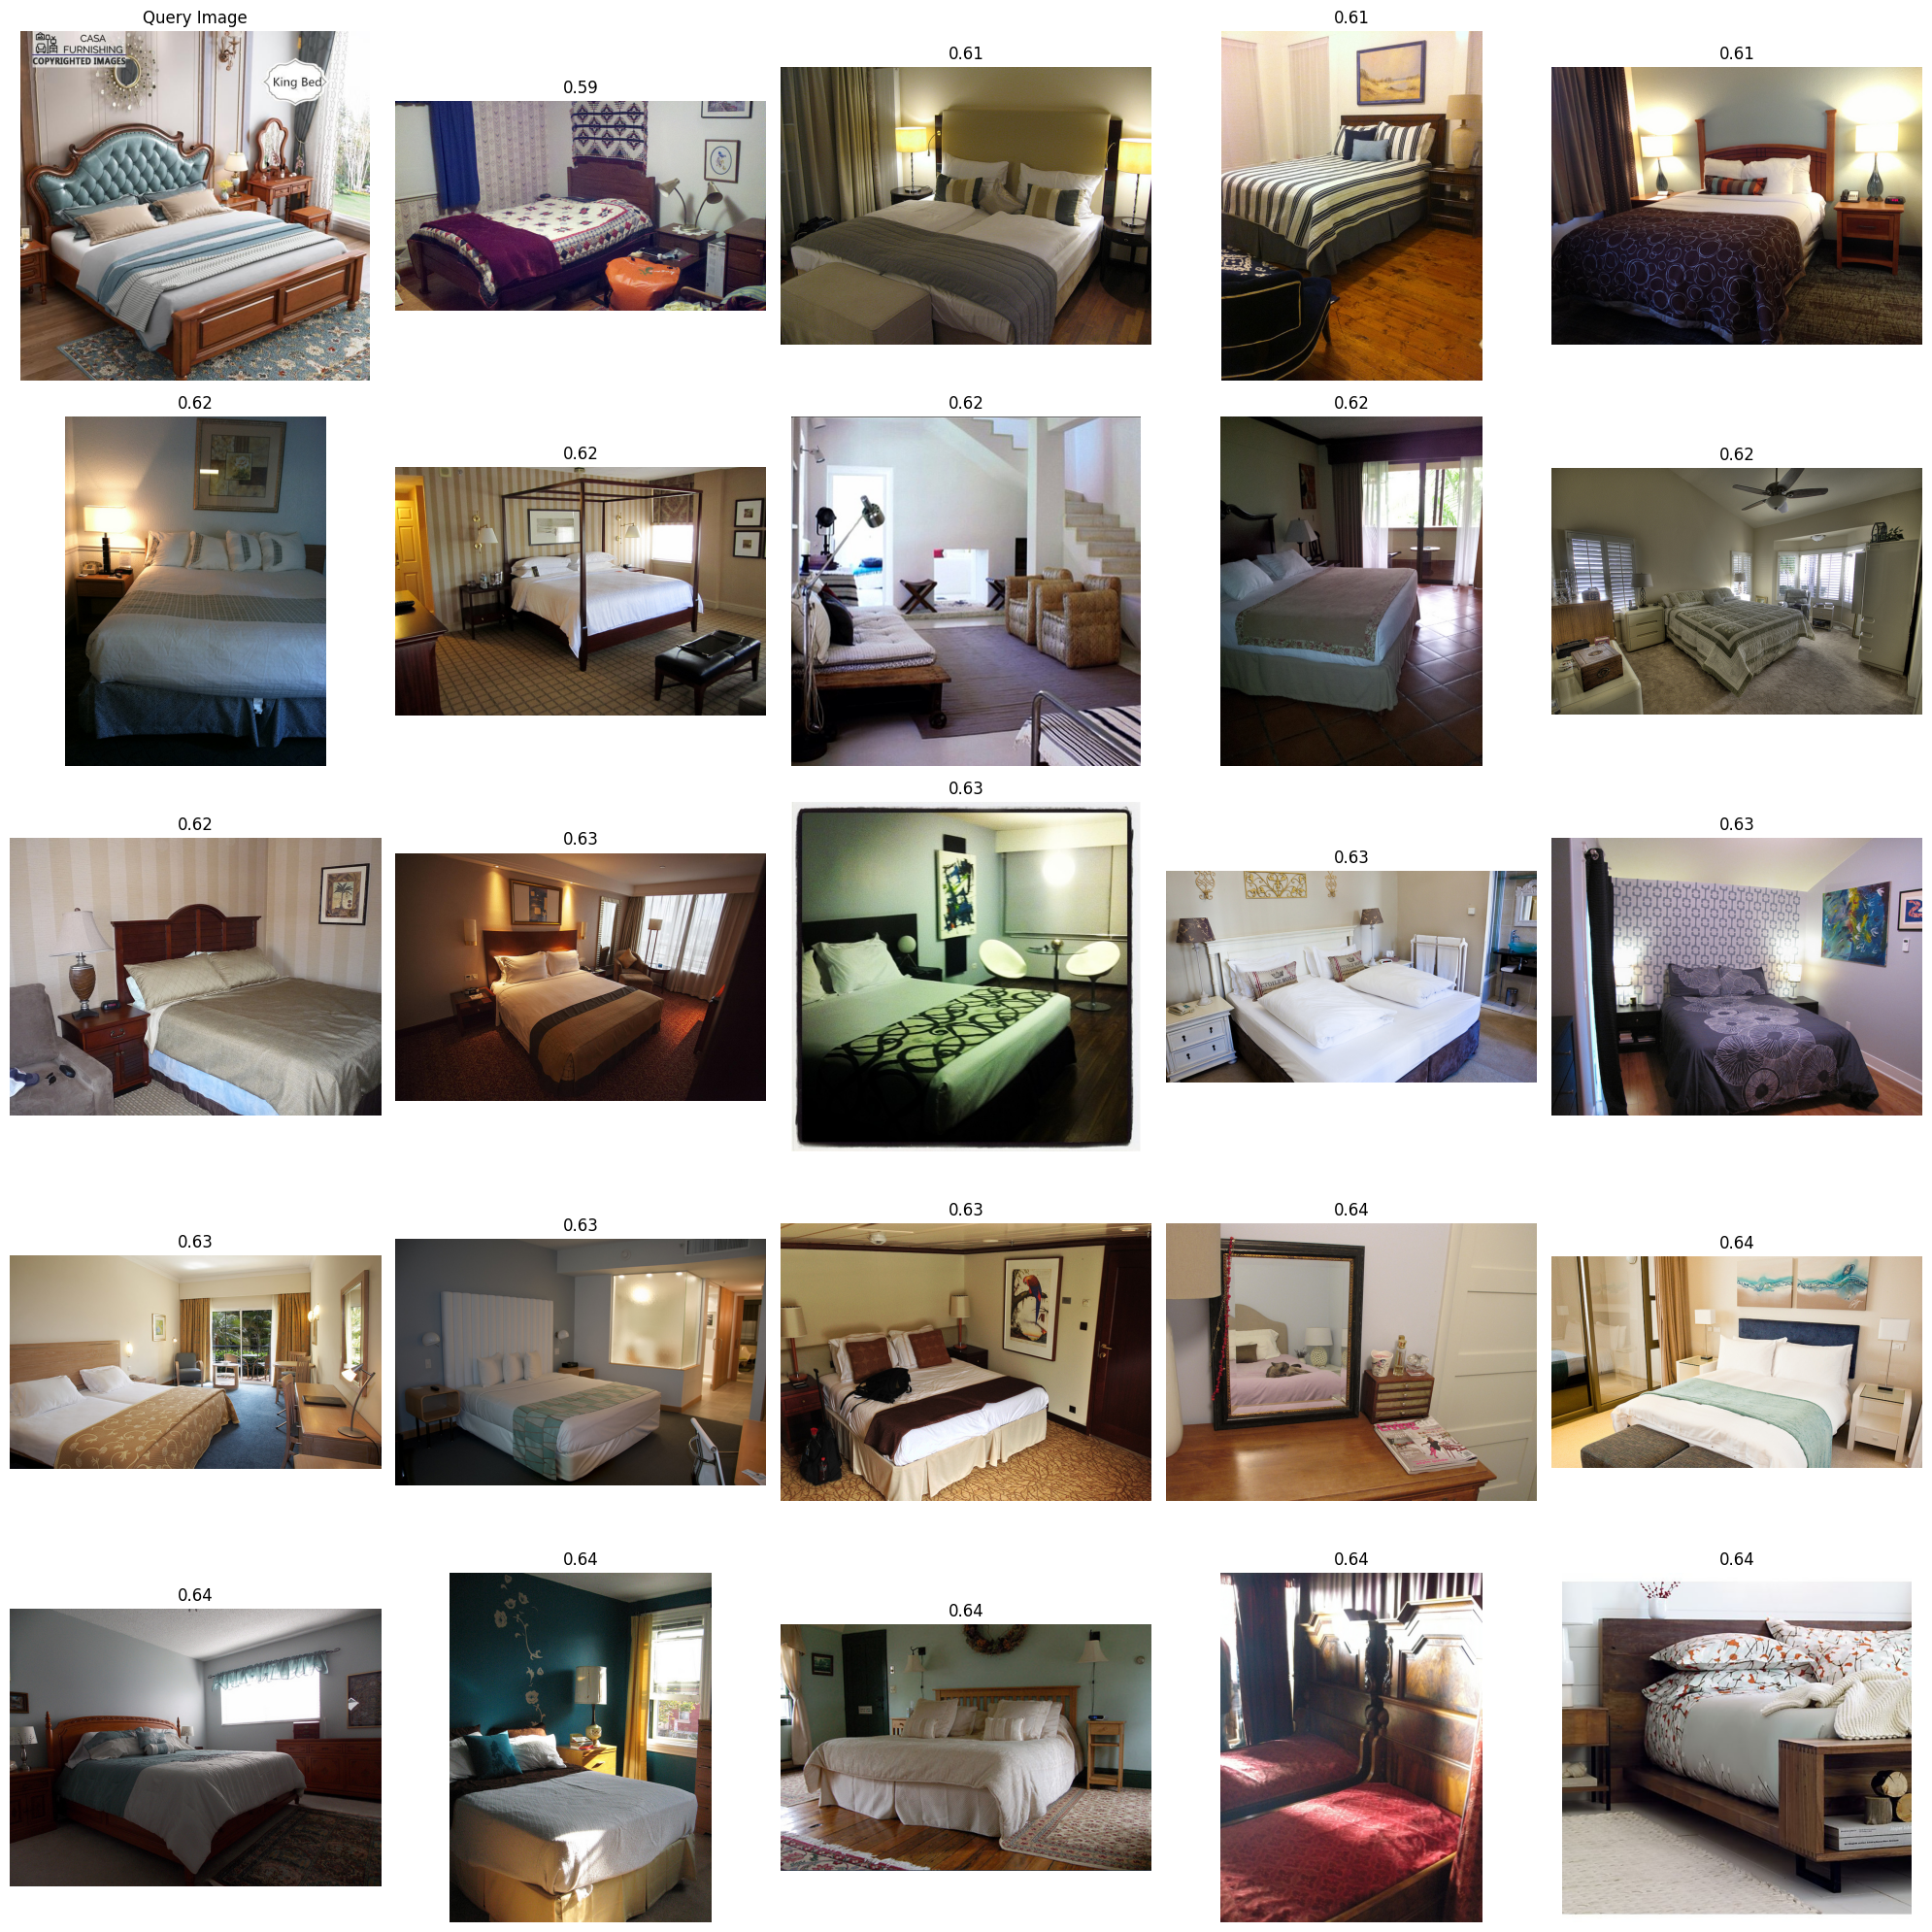

In [4]:
import torch
from torchvision import models, transforms
import torch.nn as nn
from PIL import Image
import numpy as np
from annoy import AnnoyIndex
import json
import os
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
IMG_SIZE = 224
EMBEDDING_DIM = 512  # Must match the embeddings used to build the index
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TOP_K = 24

# =========================
# LOAD MODEL
# =========================
weights = models.ResNet18_Weights.IMAGENET1K_V1
embedding_model = models.resnet18(weights=weights)
embedding_model.fc = nn.Identity()  # Remove final classification layer
embedding_model = embedding_model.to(DEVICE)
embedding_model.eval()

preprocess = weights.transforms()

# =========================
# LOAD ANN INDEX & IMAGE PATHS
# =========================
ANN_INDEX_PATH = "/kaggle/working/data/Bed_dataset/Bed_dataset.ann"
PATHS_FILE = "/kaggle/working/data/Bed_dataset/Bed_dataset_paths.json"

index = AnnoyIndex(EMBEDDING_DIM, 'angular')
index.load(ANN_INDEX_PATH)

with open(PATHS_FILE, "r") as f:
    image_paths = json.load(f)

# =========================
# QUERY IMAGE EMBEDDING
# =========================
def get_embedding(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = preprocess(img).unsqueeze(0).to(DEVICE)  # Add batch dim
    with torch.no_grad():
        embedding = embedding_model(img_tensor)
    embedding = embedding.cpu().numpy()[0]
    embedding /= np.linalg.norm(embedding)  # Normalize for angular distance
    return embedding

# =========================
# FIND TOP K SIMILAR IMAGES
# =========================
def search_similar(query_image_path, top_k=TOP_K):
    query_embedding = get_embedding(query_image_path)
    nearest_ids, distances = index.get_nns_by_vector(query_embedding, top_k, include_distances=True)
    results = [(image_paths[i], distances[idx]) for idx, i in enumerate(nearest_ids)]
    return results

# =========================
# DISPLAY RESULTS IN GRID
# =========================
def display_results(query_image_path, top_results):
    n_cols = 5
    n_rows = (len(top_results) + n_cols - 1) // n_cols

    plt.figure(figsize=(20, 4 * n_rows))
    
    # Show query image first
    query_img = Image.open(query_image_path).convert("RGB")
    plt.subplot(n_rows, n_cols, 1)
    plt.imshow(query_img)
    plt.title("Query Image")
    plt.axis("off")

    for i, (img_path, distance) in enumerate(top_results):
        plt.subplot(n_rows, n_cols, i + 2)  # +2 because query is first
        img = Image.open(img_path).convert("RGB")
        plt.imshow(img)
        plt.title(f"{distance:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# =========================
# USAGE
# =========================
query_image = "/kaggle/input/testimage5/upholstered-bed-Sheesham-Wood-Double-bed-1.jpg"  # Replace with your uploaded image path
top_results = search_similar(query_image)
display_results(query_image, top_results)


In [5]:
import shutil
import os
from tqdm import tqdm
from IPython.display import display, HTML

# =========================
# ZIP THE FOLDER
# =========================
folder_to_zip = "/kaggle/working/data"
output_zip = "/kaggle/working/Finaldata.zip"

print("Zipping folder...")
shutil.make_archive(base_name=output_zip.replace(".zip", ""),
                    format='zip',
                    root_dir=folder_to_zip)
print(f"Folder zipped successfully: {output_zip}")



Zipping folder...
Folder zipped successfully: /kaggle/working/Finaldata.zip
